## Sections

- Introduction
- Approach 1: Dynamic Nelson-Siegel Model
- Approach 2: Neural SDEs for dynamic models

- Interpolation can produce arbitrage opportunities.
    - For example, negative forward rates or non-monotonic discount factors.
    - Even with negative rates, log-discounts produce flat forward rates between points.
- We do not observe the instantaneous forward rate directly.
- We want to ensure that the forward rate curves are arbitrage-free over time.
- We can define a model for the instantaneous forward rate dynamics that ensures no arbitrage.
- This selections needs to be consitent with the forward rate model we use for pricing (needs to be in the span)

In [139]:
import pandas as pd
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from __future__ import annotations
from dataclasses import dataclass, field
import numpy as np

In [140]:
df = pd.read_excel("discounts.xlsx", index_col='date', parse_dates=['date'])
df = df.dropna()

In [141]:
ref_date = df.index[-5]
discounts = df.loc[ref_date]
tenors = discounts.index.astype(np.float64).to_numpy()

In [142]:
def _pchip_slopes(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Fritsch-Carlson monotone slopes for piecewise cubic Hermite (PCHIP).
    Returns m[i] ~ dy/dx at each knot x[i].
    """
    if not isinstance(x, np.ndarray) or not isinstance(y, np.ndarray):
        raise TypeError("x and y must be numpy arrays")
    if x.ndim != 1 or y.ndim != 1 or x.size != y.size:
        raise ValueError("x and y must be 1D arrays of equal length")

    n = x.size
    if n < 2:
        return np.zeros_like(x)

    h = np.diff(x)
    if np.any(h <= 0):
        raise ValueError("tenors must be strictly increasing")

    delta = np.diff(y) / h
    m = np.zeros(n, dtype=y.dtype)

    if n == 2:
        m[:] = delta[0]
        return m

    # Endpoint estimates + limiting
    m0 = ((2 * h[0] + h[1]) * delta[0] - h[0] * delta[1]) / (h[0] + h[1])
    mn = ((2 * h[-1] + h[-2]) * delta[-1] - h[-1] * delta[-2]) / (h[-1] + h[-2])

    def _limit_endpoint(me, de):
        if me * de <= 0:
            return 0.0 * me
        if np.abs(me) > 3 * np.abs(de):
            return 3 * de
        return me

    m[0] = _limit_endpoint(m0, delta[0])
    m[-1] = _limit_endpoint(mn, delta[-1])

    # Interior points (weighted harmonic mean, with sign/flat checks)
    for k in range(1, n - 1):
        if delta[k - 1] == 0 or delta[k] == 0 or (delta[k - 1] * delta[k] < 0):
            m[k] = 0.0 * delta[k]
        else:
            w1 = 2 * h[k] + h[k - 1]
            w2 = h[k] + 2 * h[k - 1]
            m[k] = (w1 + w2) / (w1 / delta[k - 1] + w2 / delta[k])

    return m


def _hermite_eval_and_deriv(
    x: np.ndarray, y: np.ndarray, m: np.ndarray, xq
) -> tuple[np.ndarray, np.ndarray]:
    """
    Evaluate y(xq) and dy/dx(xq) for piecewise cubic Hermite interpolation.
    Linear extrapolation using endpoint slopes.

    x, y, m must be numpy arrays.
    xq can be a numpy array or a scalar; if scalar, it is wrapped once into a 0d/1d array.
    """
    if not (isinstance(x, np.ndarray) and isinstance(y, np.ndarray) and isinstance(m, np.ndarray)):
        raise TypeError("x, y, m must be numpy arrays")
    if x.ndim != 1 or y.ndim != 1 or m.ndim != 1 or x.size != y.size or x.size != m.size:
        raise ValueError("x, y, m must be 1D arrays of equal length")

    xq_arr = xq if isinstance(xq, np.ndarray) else np.array(xq)

    yq = np.empty_like(xq_arr, dtype=y.dtype)
    dyq = np.empty_like(xq_arr, dtype=y.dtype)

    left = xq_arr <= x[0]
    right = xq_arr >= x[-1]
    mid = ~(left | right)

    # Linear extrapolation
    if np.any(left):
        dx = xq_arr[left] - x[0]
        yq[left] = y[0] + m[0] * dx
        dyq[left] = m[0]

    if np.any(right):
        dx = xq_arr[right] - x[-1]
        yq[right] = y[-1] + m[-1] * dx
        dyq[right] = m[-1]

    # Hermite on each interval
    if np.any(mid):
        i = np.searchsorted(x, xq_arr[mid], side="right") - 1
        i = np.clip(i, 0, x.size - 2)

        x0 = x[i]
        x1 = x[i + 1]
        h = x1 - x0
        s = (xq_arr[mid] - x0) / h  # in [0,1]

        y0 = y[i]
        y1 = y[i + 1]
        m0 = m[i]
        m1 = m[i + 1]

        s2 = s * s
        s3 = s2 * s

        h00 = 2 * s3 - 3 * s2 + 1
        h10 = s3 - 2 * s2 + s
        h01 = -2 * s3 + 3 * s2
        h11 = s3 - s2

        yq[mid] = h00 * y0 + h10 * h * m0 + h01 * y1 + h11 * h * m1

        dh00 = 6 * s2 - 6 * s
        dh10 = 3 * s2 - 4 * s + 1
        dh01 = -6 * s2 + 6 * s
        dh11 = 3 * s2 - 2 * s

        dyq[mid] = (dh00 * y0 + dh10 * h * m0 + dh01 * y1 + dh11 * h * m1) / h

    return yq, dyq


class Curve:
    """
    Discount curve with PCHIP (shape-preserving cubic Hermite) interpolation on log(discount factors).
    """

    def __init__(self, tenors: np.ndarray, dfs: np.ndarray, *, copy: bool = True):
        if not isinstance(tenors, np.ndarray) or not isinstance(dfs, np.ndarray):
            raise TypeError("tenors and dfs must be numpy arrays")
        if tenors.ndim != 1 or dfs.ndim != 1 or tenors.size != dfs.size:
            raise ValueError("tenors and dfs must be 1D arrays of equal length")
        if tenors.size < 2:
            raise ValueError("need at least 2 curve points")
        if np.any(dfs <= 0):
            raise ValueError("dfs must be > 0")

        # Sort by tenor
        idx = np.argsort(tenors)
        t = tenors[idx]
        df = dfs[idx]
        if np.any(np.diff(t) <= 0):
            raise ValueError("tenors must be strictly increasing")

        if copy:
            t = t.copy()
            df = df.copy()

        log_df = np.log(df)
        dlog_df_dt = _pchip_slopes(t, log_df)

        self.tenors = t
        self.dfs = df
        self._log_dfs = log_df
        self._dlog_df_dt = dlog_df_dt


    def log_discount(self, T):
        y, _ = _hermite_eval_and_deriv(self.tenors, self._log_dfs, self._dlog_df_dt, T)
        return y

    def discount(self, T):
        return np.exp(self.log_discount(T))

    def inst_fwd(self, T):
        _, dy = _hermite_eval_and_deriv(self.tenors, self._log_dfs, self._dlog_df_dt, T)
        return -dy

    def fwd_rate(self, T1, T2):
        if T2 <= T1:
            return np.nan
        log_df1 = self.log_discount(T1)
        log_df2 = self.log_discount(T2)
        return -(log_df2 - log_df1) / (T2 - T1)


In [143]:
curve = Curve(tenors=tenors, dfs=discounts.values)

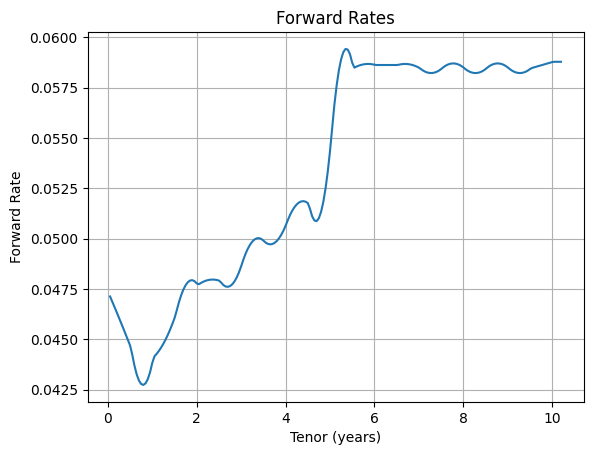

In [144]:
yfs = np.arange(0.05, 10.25, 0.05)
fwd_rates = [curve.fwd_rate(t - 0.05, t) for t in yfs]
plt.plot(yfs, fwd_rates)
plt.title("Forward Rates")
plt.xlabel("Tenor (years)")
plt.ylabel("Forward Rate")
plt.grid()
plt.show()


Svenson

$$
f(\tau) = \beta_0 + \beta_1 \exp\!\left(-\frac{\tau}{\nu_1}\right)
          + \beta_2 \frac{\tau}{\nu_1} \exp\!\left(-\frac{\tau}{\nu_1}\right),
$$
where $\beta_0$ and $\nu_1$ are positive constants. Integration yields

$$
\widehat{P}(\tau)
  = e^{-\int_0^{\tau} f(s)\,ds}
  = \exp\!\left[
      -\big(
        \beta_0 \tau
        + \beta_1 (-\nu_1 e^{-\tau/\nu_1} - \nu_1)
        + \beta_2 (-e^{-\tau/\nu_1}(\tau+\nu_1) + \nu_1)
      \big)
    \right].
$$


NSS, consistent with the HJM framework:

$$
f(t, t+\tau) = z_{1,t} + z_{2,t}\tau + z_{3,t}e^{-a\tau} + z_{4,t}\tau e^{-a\tau}+ z_{5,t} e^{-2a\tau}
$$


In [145]:
class NelsonSiegelCurve:
  
    def __init__(self, params: np.ndarray):
        self.p = params  # shape (4,)

    def inst_fwd(self, tau: np.ndarray) -> np.ndarray:
        b0, b1, b2, nu1 = self.p
        e = np.exp(-tau / nu1)
        return b0 + b1 * e + b2 * (tau / nu1) * e

    def log_discount(self, T: np.ndarray) -> np.ndarray:
        b0, b1, b2, nu1 = self.p
        one_minus_e = -np.expm1(-T / nu1)      # 1 - exp(-T/nu1)
        e = np.exp(-T / nu1)
        integral = b0 * T + b1 * nu1 * one_minus_e + b2 * (nu1 * one_minus_e - T * e)
        return -integral

    def discount(self, T: np.ndarray) -> np.ndarray:
        return np.exp(self.log_discount(T))

    def fwd_rate(self, T1: np.ndarray, T2: np.ndarray) -> np.ndarray:
        # simple forward over [T1,T2]
        return (self.log_discount(T1) - self.log_discount(T2)) / (T2 - T1)


class SvenssonNSSCurve:
    """
    params = [b0, b1, b2, b3, nu1, nu2]
    f(tau) = b0 + b1 exp(-tau/nu1) + b2 (tau/nu1) exp(-tau/nu1) + b3 (tau/nu2) exp(-tau/nu2)
    P(0,T) = exp(-∫_0^T f(s) ds)  (closed form)
    """

    def __init__(self, params: np.ndarray):
        self.p = params  # shape (6,)

    def inst_fwd(self, tau: np.ndarray) -> np.ndarray:
        b0, b1, b2, b3, nu1, nu2 = self.p
        e1 = np.exp(-tau / nu1)
        e2 = np.exp(-tau / nu2)
        return b0 + b1 * e1 + b2 * (tau / nu1) * e1 + b3 * (tau / nu2) * e2

    def log_discount(self, T: np.ndarray) -> np.ndarray:
        b0, b1, b2, b3, nu1, nu2 = self.p
        one_minus_e1 = -np.expm1(-T / nu1)
        one_minus_e2 = -np.expm1(-T / nu2)
        e1 = np.exp(-T / nu1)
        e2 = np.exp(-T / nu2)
        integral = (
            b0 * T
            + b1 * nu1 * one_minus_e1
            + b2 * (nu1 * one_minus_e1 - T * e1)
            + b3 * (nu2 * one_minus_e2 - T * e2)
        )
        return -integral

    def discount(self, T: np.ndarray) -> np.ndarray:
        return np.exp(self.log_discount(T))

    def fwd_rate(self, T1: np.ndarray, T2: np.ndarray) -> np.ndarray:
        return (self.log_discount(T1) - self.log_discount(T2)) / (T2 - T1)


In [146]:
# %%
def _rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def calibrate_ns_to_dfs(tenors, dfs, x0=None):
    """
    Calibrate Nelson-Siegel (forward-form) to discount factors by minimizing
    SSE on log-discounts: logP_model(T) vs logP_mkt(T).
    """
    tenors = np.asarray(tenors, float)
    dfs = np.asarray(dfs, float)
    y = np.log(dfs)

    if x0 is None:
        # crude init
        b0 = -np.log(dfs[-1]) / tenors[-1]
        x0 = np.array([b0, 0.0, 0.0, 2.0], float)  # [b0,b1,b2,nu1]

    bounds = [(-2.0, 2.0), (-5.0, 5.0), (-5.0, 5.0), (1e-3, 50.0)]  # nu1 > 0

    def obj(x):
        c = NelsonSiegelCurve(x)
        return np.mean((c.log_discount(tenors) - y) ** 2)

    res = minimize(obj, x0=x0, method="L-BFGS-B", bounds=bounds)
    params = res.x
    curve_fit = NelsonSiegelCurve(params)

    return params, res, curve_fit


def calibrate_nss_to_dfs(tenors, dfs, x0=None):
    """
    Calibrate Svensson/NSS (forward-form) to discount factors by minimizing
    SSE on log-discounts: logP_model(T) vs logP_mkt(T).
    """
    tenors = np.asarray(tenors, float)
    dfs = np.asarray(dfs, float)
    y = np.log(dfs)

    if x0 is None:
        b0 = -np.log(dfs[-1]) / tenors[-1]
        x0 = np.array([b0, 0.0, 0.0, 0.0, 2.0, 5.0], float)  # [b0,b1,b2,b3,nu1,nu2]

    bounds = [
        (-2.0, 2.0),   # b0
        (-5.0, 5.0),   # b1
        (-5.0, 5.0),   # b2
        (-5.0, 5.0),   # b3
        (1e-3, 50.0),  # nu1 > 0
        (1e-3, 50.0),  # nu2 > 0
    ]

    def obj(x):
        c = SvenssonNSSCurve(x)
        return np.mean((c.log_discount(tenors) - y) ** 2)

    res = minimize(obj, x0=x0, method="L-BFGS-B", bounds=bounds)
    params = res.x
    curve_fit = SvenssonNSSCurve(params)

    return params, res, curve_fit


In [147]:
# %%
ns_params, ns_res, ns_curve = calibrate_ns_to_dfs(tenors, discounts.values)
nss_params, nss_res, nss_curve = calibrate_nss_to_dfs(tenors, discounts.values)

print("NS params  [b0,b1,b2,nu1]:", ns_params)
print("NS success:", ns_res.success, "fun:", ns_res.fun)

print("\nNSS params [b0,b1,b2,b3,nu1,nu2]:", nss_params)
print("NSS success:", nss_res.success, "fun:", nss_res.fun)


NS params  [b0,b1,b2,nu1]: [ 0.06125293 -0.01494039 -0.02532213  2.00022956]
NS success: True fun: 9.354575061372995e-07

NSS params [b0,b1,b2,b3,nu1,nu2]: [ 5.19993030e-02 -3.13492708e-03 -3.55799690e-02  2.95002624e-02
  1.99911360e+00  5.00014464e+00]
NSS success: True fun: 6.67461386130432e-07


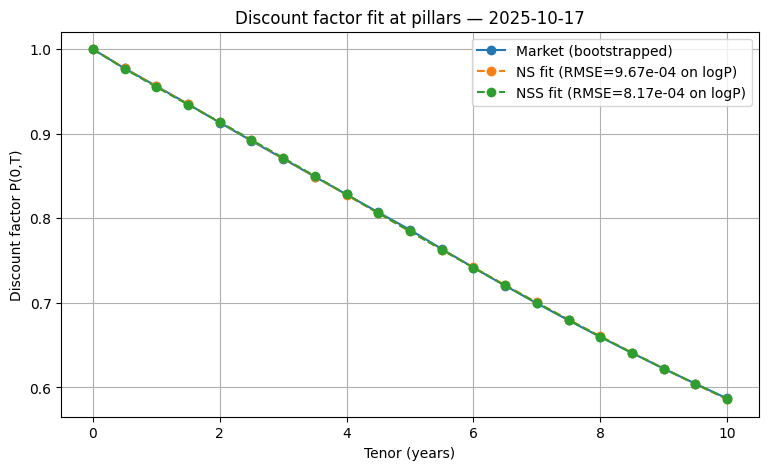

In [148]:
# %%
P_mkt = discounts.values
P_ns  = ns_curve.discount(tenors)
P_nss = nss_curve.discount(tenors)

plt.figure(figsize=(9,5))
plt.plot(tenors, P_mkt, "o-", label="Market (bootstrapped)")
plt.plot(tenors, P_ns,  "o--", label=f"NS fit (RMSE={_rmse(np.log(P_ns), np.log(P_mkt)):.2e} on logP)")
plt.plot(tenors, P_nss, "o--", label=f"NSS fit (RMSE={_rmse(np.log(P_nss), np.log(P_mkt)):.2e} on logP)")
plt.title(f"Discount factor fit at pillars — {ref_date.date()}")
plt.xlabel("Tenor (years)")
plt.ylabel("Discount factor P(0,T)")
plt.grid(True)
plt.legend()
plt.show()


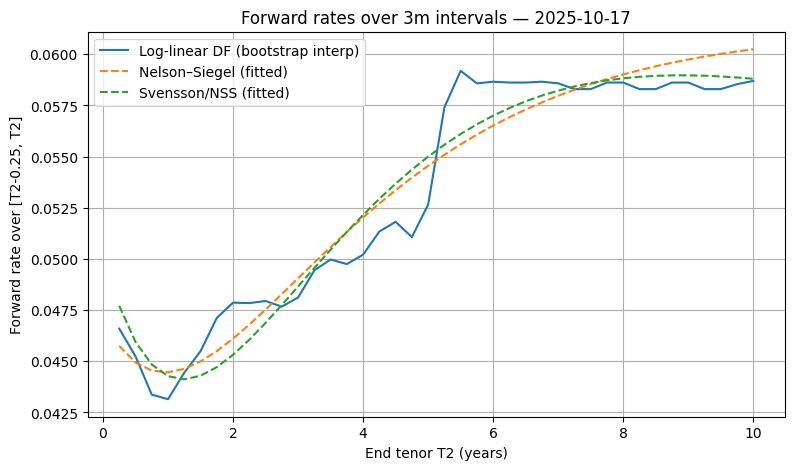

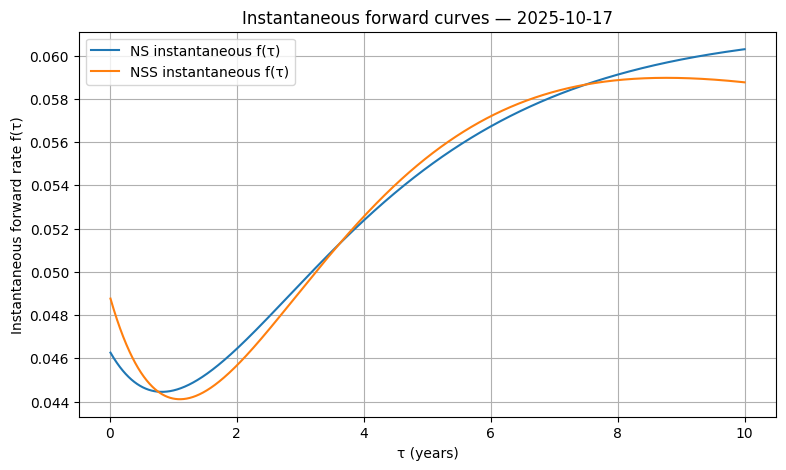

In [149]:
# %%
# Rolling forward rates (same definition as your Curve via DF ratio)
yfs = np.arange(0.25, 10.25, 0.25)
T1 = yfs - 0.25
T2 = yfs

fwd_ll = np.array([curve.fwd_rate(t1, t2) for t1, t2 in zip(T1, T2)])
fwd_ns  = ns_curve.fwd_rate(T1, T2)
fwd_nss = nss_curve.fwd_rate(T1, T2)

plt.figure(figsize=(9,5))
plt.plot(yfs, fwd_ll, label="Log-linear DF (bootstrap interp)")
plt.plot(yfs, fwd_ns,  "--", label="Nelson–Siegel (fitted)")
plt.plot(yfs, fwd_nss, "--", label="Svensson/NSS (fitted)")
plt.title(f"Forward rates over 3m intervals — {ref_date.date()}")
plt.xlabel("End tenor T2 (years)")
plt.ylabel("Forward rate over [T2-0.25, T2]")
plt.grid(True)
plt.legend()
plt.show()

# Optional: instantaneous forwards on a fine grid
tau_grid = np.linspace(0.01, 10.0, 2000)
plt.figure(figsize=(9,5))
plt.plot(tau_grid, ns_curve.inst_fwd(tau_grid),  label="NS instantaneous f(τ)")
plt.plot(tau_grid, nss_curve.inst_fwd(tau_grid), label="NSS instantaneous f(τ)")
plt.title(f"Instantaneous forward curves — {ref_date.date()}")
plt.xlabel("τ (years)")
plt.ylabel("Instantaneous forward rate f(τ)")
plt.grid(True)
plt.legend()
plt.show()


In [150]:
class TimeConsistentNSCurve:
    def __init__(self, alpha: np.ndarray, z_params: np.ndarray, vol_params: np.ndarray):
        self.z = z_params  # shape (7,)
        self.vols = vol_params
        self.alpha = alpha
    
    def inst_fwd(self, tau):
        t1 = self.z[1]*tau
        t2 = self.z[2]*np.exp(-self.alpha*tau)
        t3 = self.z[3]*tau*np.exp(-self.alpha*tau)
        t4 = self.z[4]*np.exp(-2*self.alpha*tau)
        return self.z[0] + t1 + t2 + t3 + t4

In [151]:
pillars = np.arange(0, 5.25, 0.25)
dt = 1/360
q = np.zeros(shape=(df.shape[0]-1,pillars.shape[0]))
tol = 0

# initial fit
model = TimeConsistentNSCurve()

while tol<1e-2:    
    for i, window in enumerate(df.rolling(2)):
        if window.shape[0] >1:
            c1 = Curve(tenors=tenors, dfs=window.iloc[0])
            c2 = Curve(tenors=tenors, dfs=window.iloc[1])
            dfs1 = c1.discount(pillars)
            dfs2 = c2.discount(pillars)
            r0 = (1/c2.discount(dt)-1)/dt
            q[i-1,:] = (dfs2 - dfs1)/dfs1 - r0*dt

TypeError: TimeConsistentNSCurve.__init__() missing 3 required positional arguments: 'alpha', 'z_params', and 'vol_params'

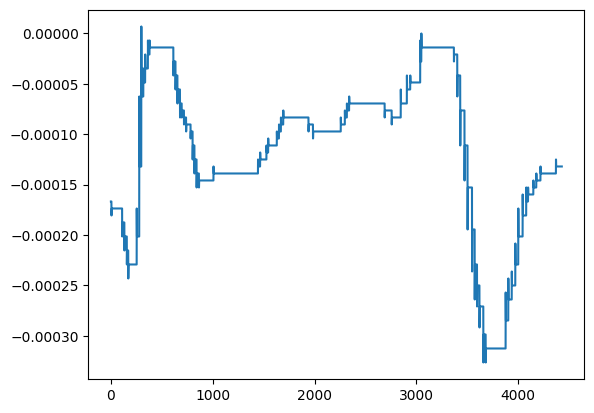

In [ ]:
plt.plot(q[:,0])